# Camino Example Workflow

We're going to use `camino` to fit a single JWST defocused imaging dataset, initializing at zero OPD across the full pupil.

In [1]:
from pathlib import Path

from camino.fitting import FitConfig, load_data, fit_data
from camino.data_utils import download_wlp8_wlm8

First, download data from MAST; we're going to go with 18 December 2025, for no particular reason. 

In [2]:
OBS_DATE = "2025-12-18"
FIT_MODE = "pixel"

date_tag = OBS_DATE.replace("-", "")
mode_tag = FIT_MODE.replace("_", "")

OUTPUT_DIR = Path(f"{date_tag}_{mode_tag}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WLP8_IMAGE_PATH, WLM8_IMAGE_PATH = download_wlp8_wlm8(
    OBS_DATE,
    download_dir=OUTPUT_DIR / "data",
)

config = FitConfig.for_mode(
    FIT_MODE,
    show_plots=True,
)

Date     : 2025-12-18
OPD      : O2025121801
Detector : NRCA1
WLM8     : jw07464177001_03104_00001 | 2025-12-17T08:00:43.4780000
WLP8     : jw07464177001_03105_00001 | 2025-12-17T08:05:01.1410000
Already exists: jw07464177001_03104_00001_nrca1_cal.fits
Already exists: jw07464177001_03105_00001_nrca1_cal.fits


Load the data into a format `camino` can work with.

In [3]:
data = load_data(
    WLP8_IMAGE_PATH,
    WLM8_IMAGE_PATH,
    config=config,
)

Initialize the OPD at zero and fit by stochastic gradient descent, progressively adding in more features until we have a decent initialization point for a fast BFGS fit.

CAMINO pixel: 128x128 cutouts; zero initial OPD


Stage 1 — SGD defocus and positions: 100%|██████████| 60/60 [00:05<00:00, 10.10it/s, loss=7.515393e+06]


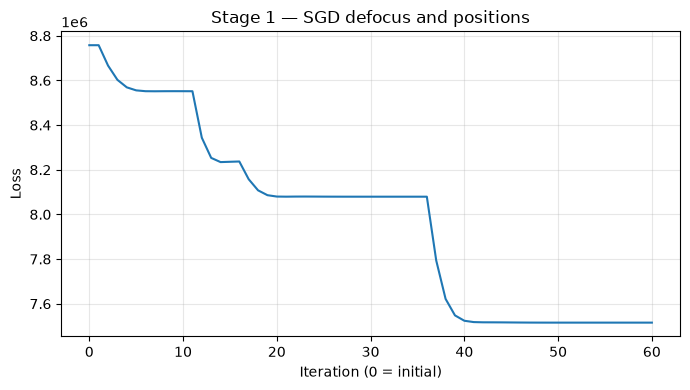

Stage 2 — L-BFGS-B: 100%|██████████| 75/75 [00:06<00:00, 11.23iter/s, grad=4.378e-03, loss=4.346650e+05]


Stage 2 — L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=75, loss=4.34665027e+05


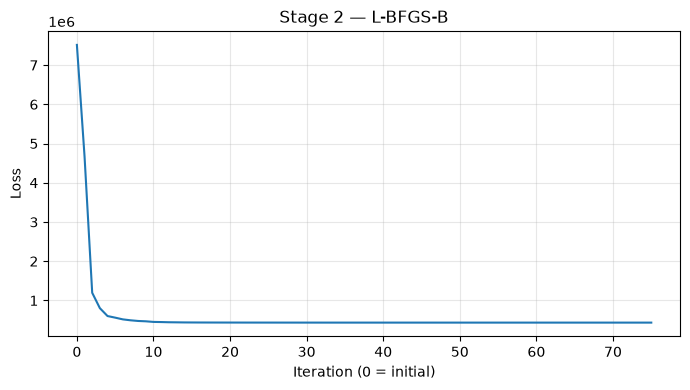

CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [4]:
# 3. Fit from zero; loss curves are displayed and results are saved.
result = fit_data(data=data, output_dir=OUTPUT_DIR)
print(result.scipy_result.message)


That converged pretty fast! It should converge even faster on a GPU. Let's check out a comparison to the MAST saved OPD maps - we should do a lot better:

iterating query, tdelta=3.0

MAST OPD query around UTC: 2025-12-18T12:00:00.000
                        MJD: 61027.5

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2025121801-NRCA1_FP6-1.fits
	Date (MJD):	 61026.3338
	Delta time:	 -1.1662 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2025122101-NRCA1_FP6-1.fits
	Date (MJD):	 61030.3798
	Delta time:	 2.8798 days
User requested choosing OPD time closest in time to 2025-12-18T12:00:00.000, which is O2025121801-NRCA1_FP6-1.fits, delta time -1.166 days
MAST WSS: O2025121801-NRCA1_FP6-1.fits
WLP8: CAMINO mean(z²)=13.543; MAST mean(z²)=65.806
WLM8: CAMINO mean(z²)=12.960; MAST mean(z²)=63.109


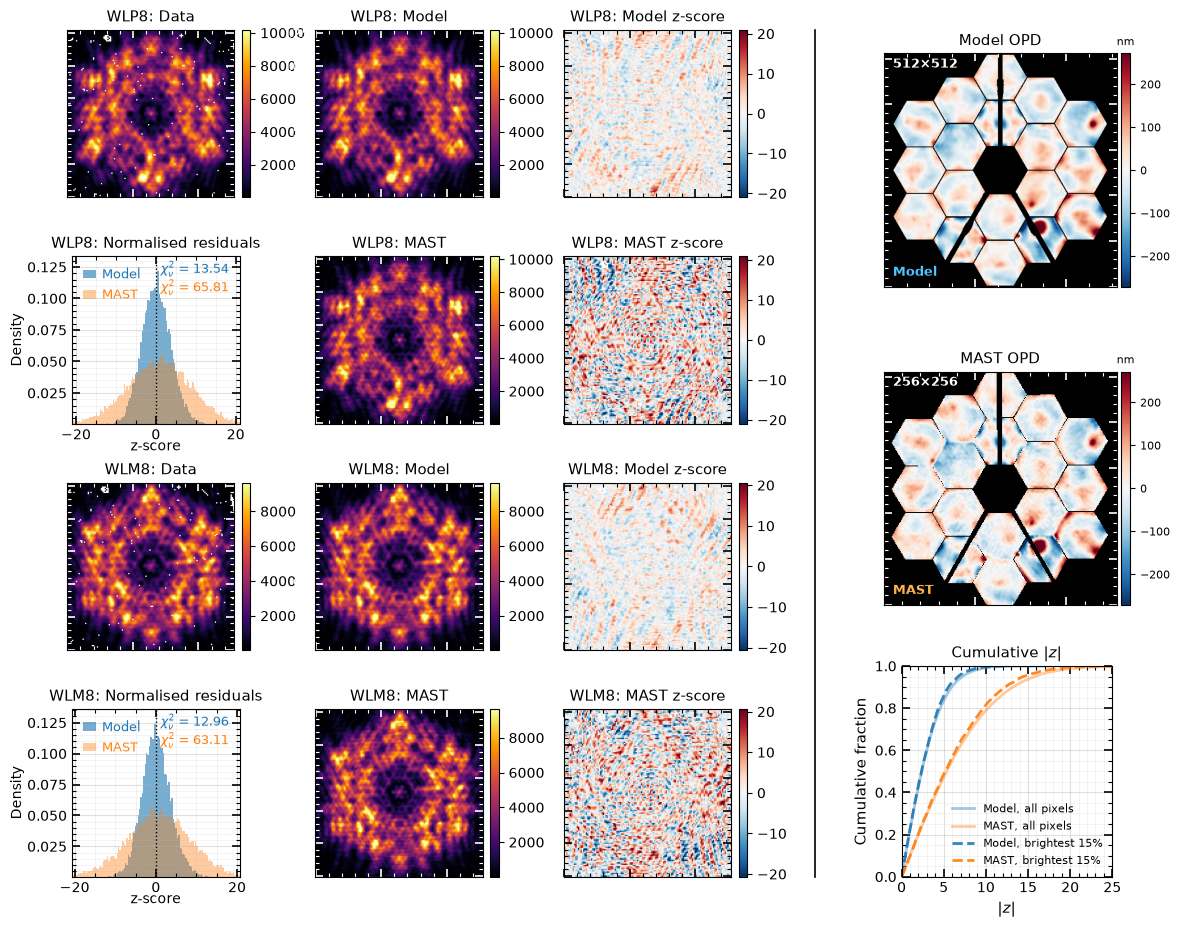

In [5]:
# 4. Compare with MAST; displays the figure and saves PNG/PDF in OUTPUT_DIR.
from camino.fitting import get_mast_wss_path

MAST_WSS_PATH = get_mast_wss_path(f"{OBS_DATE}T12:00:00", choice="closest")

print("MAST WSS:", MAST_WSS_PATH.name)


comparison = result.compare_with_mast(
    MAST_WSS_PATH, calc_hdu={"WLM8": 6, "WLP8": 11},
)
